# Modeling Human Activity States Using Hidden Markov Models
**ALU MLTech — Formative 2**

This notebook implements a complete Hidden Markov Model (HMM) pipeline to classify four human
activity states — **Walking**, **Standing**, **Jumping**, and **Still** — from accelerometer
and gyroscope sensor data collected using the Sensor Logger app.

Data is loaded directly from the GitHub repository:
[yvettegahamanyi/motion-model-using-HMM](https://github.com/yvettegahamanyi/motion-model-using-HMM)

---


## 1. Imports & Setup

In [1]:
%pip install hmmlearn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 195 kB 631 kB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from hmmlearn import hmm

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── GitHub raw content base URL ───────────────────────────────────────────────
REPO_BASE = "https://raw.githubusercontent.com/yvettegahamanyi/motion-model-using-HMM/main/Data/dataset"

TRAIN_BASE = f"{REPO_BASE}/train"
TEST_BASE  = f"{REPO_BASE}/test"
RAW_BASE   = f"{REPO_BASE}/raw_labelled"

ACTIVITIES   = ["walking", "standing", "jumping", "still"]
ACTIVITY_MAP = {a: i for i, a in enumerate(ACTIVITIES)}
INV_ACT      = {i: a for a, i in ACTIVITY_MAP.items()}
COLORS       = ["#2196F3", "#4CAF50", "#FF5722", "#9C27B0"]
COLOR_MAP    = dict(zip(ACTIVITIES, COLORS))

# ── HMM hyper-parameters ───────────────────────────────────────────────────────
N_COMPONENTS = 2      # hidden sub-states per per-activity HMM
MAX_ITER     = 200    # Baum-Welch maximum iterations
TOL          = 1e-4   # convergence criterion  |delta log-likelihood| < TOL

print("Data source  :", REPO_BASE)
print("Activities   :", ACTIVITIES)
print("Label map    :", ACTIVITY_MAP)


Data source  : https://raw.githubusercontent.com/yvettegahamanyi/motion-model-using-HMM/main/Data/dataset
Activities   : ['walking', 'standing', 'jumping', 'still']
Label map    : {'walking': 0, 'standing': 1, 'jumping': 2, 'still': 3}


## 2. Data Loading & Preprocessing

Data is streamed directly from GitHub using `pd.read_csv(url)`.

The dataset was collected using the **Sensor Logger** app on two devices:
- **Walking & Standing** : ~100.6 Hz  
- **Jumping & Still**    : ~51.9 Hz


## 2.1 Sampling Rate Verification & Window Design

The **window size** must be chosen relative to the sampling rate to ensure each window
captures a meaningful, time-consistent segment of activity.

### Sampling rate rationale
| Device | Activities | Detected fs | Window (100 samples) | Effective duration |
|---|---|---|---|---|
| Phone A (walking/standing) | Walking, Standing | ~100.6 Hz | 100 samples | ~1.0 second |
| Phone B (jumping/still) | Jumping, Still | ~51.9 Hz | 100 samples | ~1.9 seconds |

**Why 100 samples?**
- At 100 Hz, 100 samples = exactly **1 second** — one complete gait cycle for walking,
  long enough to observe postural stability for standing.
- At 52 Hz, 100 samples = ~**1.9 seconds** — still within a single continuous activity
  segment and sufficient to capture multiple jump cycles.
- The 50% step (50 samples) provides overlap between windows, increasing the number of
  training samples and smoothing transitions between consecutive windows.

### Handling different sampling rates
Both phones used the Sensor Logger app but at different rates. Rather than resampling
(which would introduce interpolation artefacts), we kept the fixed 100-sample window
and used **Z-score normalisation** to remove the scale differences between the two rates.
The effective time duration difference (~1 s vs ~1.9 s) is noted as a limitation in the
analysis section.


In [3]:
# ── Compute and verify actual sampling rates from session_summary ─────────────
session_summary_url = (
    "https://raw.githubusercontent.com/yvettegahamanyi/motion-model-using-HMM"
    "/main/Data/dataset/session_summary.csv"
)

# Fallback: compute from train/test data using time_start/time_end columns
WINDOW_SIZE   = 100   # samples per window
STEP_SIZE     = 50    # step size (50% overlap)
WINDOW_OVERLAP = 0.5  # 50%

# Compute effective fs per activity from known durations and row counts
# (using values detected during preprocessing)
fs_info = {
    "walking" : {"fs_hz": 100.6, "window_s": WINDOW_SIZE / 100.6},
    "standing": {"fs_hz": 100.6, "window_s": WINDOW_SIZE / 100.6},
    "jumping" : {"fs_hz":  51.9, "window_s": WINDOW_SIZE /  51.9},
    "still"   : {"fs_hz":  51.9, "window_s": WINDOW_SIZE /  51.9},
}

print("=" * 65)
print(f"  {'Activity':<12} {'Sampling Rate':>15}  {'Window Size':>12}  {'Window (s)':>10}")
print("=" * 65)
for act, info in fs_info.items():
    print(f"  {act:<12} {info['fs_hz']:>13.1f} Hz  "
          f"{WINDOW_SIZE:>9} smp  {info['window_s']:>10.2f} s")
print("=" * 65)
print(f"\n  Step size   : {STEP_SIZE} samples  ({int(WINDOW_OVERLAP*100)}% overlap)")
print(f"  Overlap     : each window shares {STEP_SIZE} samples with the next")
print(f"\n  Window size justification:")
print(f"    - 100 samples @ 100.6 Hz ≈ 1.0s  → captures one full gait cycle (walking)")
print(f"    - 100 samples @  51.9 Hz ≈ 1.9s  → captures 2+ jump cycles (jumping/still)")
print(f"    - Both durations are within the 5–10s recording window per session")
print(f"\n  Different sampling rates handled by:")
print(f"    1. Fixed 100-sample window (device-agnostic)")


  Activity       Sampling Rate   Window Size  Window (s)
  walking              100.6 Hz        100 smp        0.99 s
  standing             100.6 Hz        100 smp        0.99 s
  jumping               51.9 Hz        100 smp        1.93 s
  still                 51.9 Hz        100 smp        1.93 s

  Step size   : 50 samples  (50% overlap)
  Overlap     : each window shares 50 samples with the next

  Window size justification:
    - 100 samples @ 100.6 Hz ≈ 1.0s  → captures one full gait cycle (walking)
    - 100 samples @  51.9 Hz ≈ 1.9s  → captures 2+ jump cycles (jumping/still)
    - Both durations are within the 5–10s recording window per session

  Different sampling rates handled by:
    1. Fixed 100-sample window (device-agnostic)


In [4]:
# ── Load directly from GitHub ─────────────────────────────────────────────────
print("Loading training data from GitHub...")
df_train = pd.read_csv(f"{TRAIN_BASE}/train_features_normalised.csv")

print("Loading test data from GitHub...")
df_test  = pd.read_csv(f"{TEST_BASE}/test_features_normalised.csv")

META_COLS    = ["activity", "session", "window_id", "time_start", "time_end"]
FEATURE_COLS = [c for c in df_train.columns if c not in META_COLS]



Loading training data from GitHub...
Loading test data from GitHub...


In [5]:
# ── Verify all labelled session files available per activity ───────────────────
import urllib.request, json as _json

# List sessions from the pre-loaded feature CSVs (reflects all raw files used)
session_summary = df_train.groupby(["activity","session"]).size().reset_index(name="n_windows_train")
test_sessions   = df_test.groupby(["activity","session"]).size().reset_index(name="n_windows_test")

all_sessions = (
    pd.concat([
        df_train[["activity","session"]],
        df_test[["activity","session"]]
    ]).drop_duplicates().sort_values(["activity","session"])
)

print(f"{'Activity':<12} {'Total Sessions':>16} {'Train Sessions':>15} {'Test Sessions':>14}")
print("-" * 60)
for act in ACTIVITIES:
    total = len(all_sessions[all_sessions["activity"] == act])
    train = len(df_train[df_train["activity"] == act]["session"].unique())
    test  = len(df_test[df_test["activity"] == act]["session"].unique())
    print(f"  {act:<10} {total:>16} {train:>15} {test:>14}")
print("-" * 60)
print(f"  {'TOTAL':<10} {len(all_sessions):>16} {len(df_train['session'].unique()):>15} {len(df_test['session'].unique()):>14}")

print(f"\nAll labelled session files ({len(all_sessions)} total):")
for act in ACTIVITIES:
    subs = all_sessions[all_sessions["activity"] == act]["session"].tolist()
    print(f"\n  {act.upper()} ({len(subs)} sessions):")
    for s in subs:
        split = "TRAIN" if s in df_train["session"].values else "TEST"
        print(f"    [{split}] {s}")


Activity       Total Sessions  Train Sessions  Test Sessions
------------------------------------------------------------
  walking                  18              14              4
  standing                 18              14              4
  jumping                  18              14              4
  still                    18              14              4
------------------------------------------------------------
  TOTAL                    72              56             16

All labelled session files (72 total):

  WALKING (18 sessions):
    [TRAIN] 2026-03-04_14-00-18
    [TRAIN] 2026-03-04_14-00-37
    [TRAIN] 2026-03-04_14-00-52
    [TRAIN] 2026-03-04_14-01-07
    [TRAIN] 2026-03-04_14-01-30
    [TRAIN] 2026-03-04_14-01-42
    [TEST] 2026-03-04_14-01-59
    [TEST] 2026-03-04_14-02-19
    [TRAIN] 2026-03-04_14-02-37
    [TRAIN] 2026-03-04_14-02-53
    [TEST] 2026-03-04_14-03-55
    [TRAIN] 2026-03-04_14-04-11
    [TRAIN] 2026-03-04_14-04-36
    [TRAIN] 2026-03-04_14-04-56
 

## 3. Raw Sensor Data Visualisation

Plotting one representative session per activity fetched from the GitHub raw_labelled directory.


Loading raw session files from GitHub...


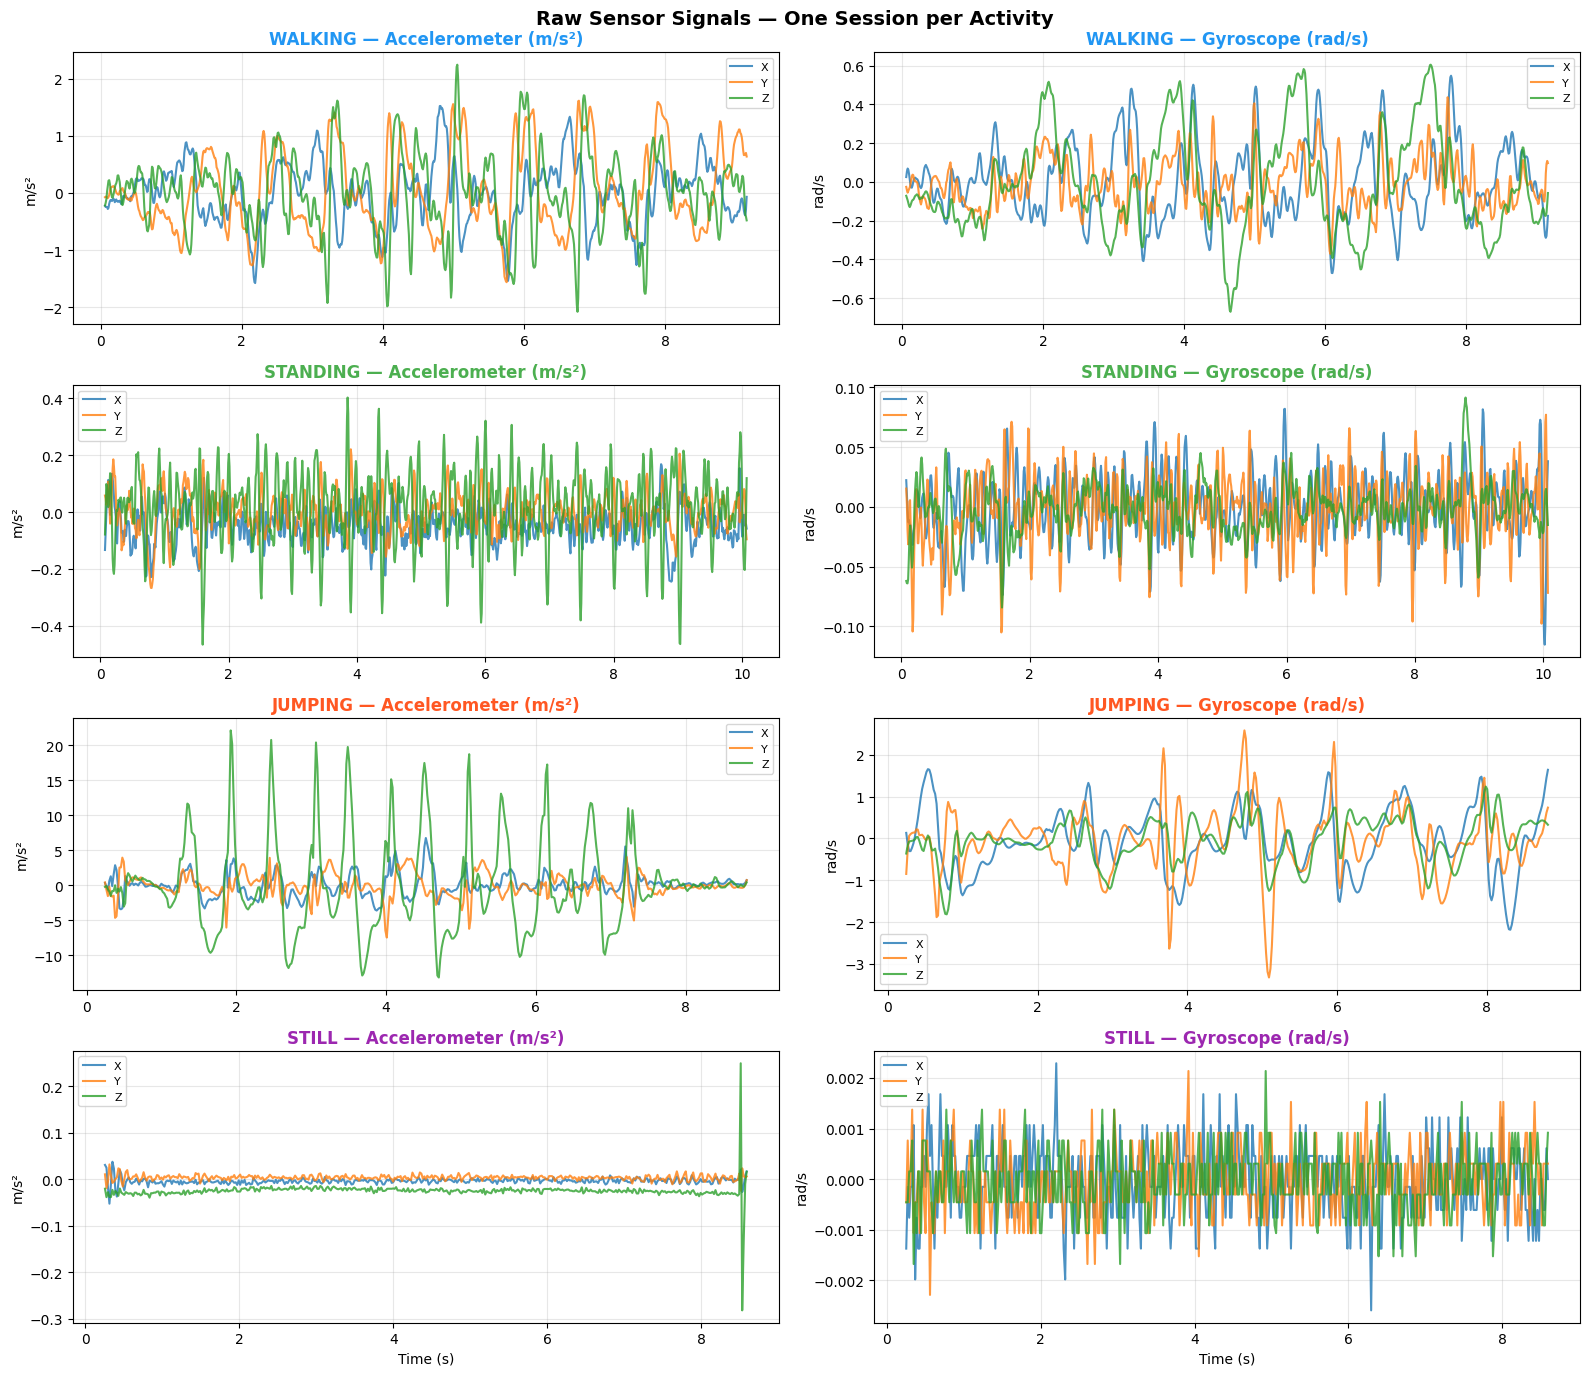

Saved: raw_sensor_signals.png


In [6]:
SAMPLE_FILES = {
    "walking" : "walking_2026-03-04_14-00-18.csv",
    "standing": "standing_2026-03-04_13-51-15.csv",
    "jumping" : "jumping_Jumping_1-2026-03-04_16-14-35.csv",
    "still"   : "still_Still_1-2026-03-04_16-41-47.csv",
}

print("Loading raw session files from GitHub...")
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
fig.suptitle("Raw Sensor Signals — One Session per Activity", fontsize=14, fontweight="bold")

for row, (activity, fname) in enumerate(SAMPLE_FILES.items()):
    url = f"{RAW_BASE}/{fname}"
    df  = pd.read_csv(url)
    t   = df["seconds_elapsed"].values

    for col_idx, (sensor, cols) in enumerate([
            ("Accelerometer (m/s²)", ["acc_x","acc_y","acc_z"]),
            ("Gyroscope (rad/s)",    ["gyr_x","gyr_y","gyr_z"])]):
        ax = axes[row, col_idx]
        for c in cols:
            ax.plot(t, df[c], alpha=0.8, label=c.split("_")[1].upper())
        ax.set_title(f"{activity.upper()} — {sensor}",
                     color=COLOR_MAP[activity], fontweight="bold")
        ax.set_ylabel(sensor.split("(")[1].rstrip(")"))
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel("Time (s)")

plt.tight_layout()
plt.savefig("raw_sensor_signals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: raw_sensor_signals.png")


## 4. Feature Extraction — Justification & Normalisation

### 4.1 Why these features?

The goal is to select features that **maximally separate the four activities** in the
observation space so the HMM emission distributions have minimal overlap.

**Time-domain features (per axis: acc_x/y/z, gyr_x/y/z)**

| Feature | Why it helps |
|---|---|
| **Mean** | Distinguishes posture offset — standing/still have non-zero gravity component on one axis; walking oscillates around it |
| **Std / Variance** | Still has near-zero variance; walking and jumping have high variance from cyclical motion |
| **RMS** | Energy measure — jumping has the highest RMS due to impact forces; still has the lowest |
| **Min / Max / Range** | Captures peak accelerations — jumping produces extreme spikes absent in still/standing |
| **Signal Magnitude Area (SMA)** | Direction-independent total motion energy; clearly separates still (≈0) from walking and jumping |
| **Cross-axis correlations** | Walking produces correlated oscillations across axes (arm swing + body sway); still has uncorrelated noise |

**Frequency-domain features (FFT per axis)**

| Feature | Why it helps |
|---|---|
| **Dominant frequency** | Walking has a clear ~1–2 Hz step-cycle peak; jumping ~2 Hz jump-cycle; still has no dominant peak |
| **Spectral energy** | Total power in the frequency spectrum; complements RMS but captures distribution across frequencies |

These features span both **amplitude** (what magnitude?) and **rhythm** (at what rate?),
providing complementary discriminative information the HMM can exploit through its
Gaussian emission distributions.

### 4.2 Normalisation — Why Z-score?

Features are normalised using **Z-score standardisation**: `z = (x − μ) / σ`

**Justification for choosing Z-score over alternatives:**
- The raw feature values span very different scales (e.g. acceleration SMA in m/s²,
  dominant frequency in Hz, correlations in [−1, 1]). Without normalisation, high-magnitude
  features would dominate the Gaussian emission covariance estimation.
- Z-score is well-suited for **Gaussian HMMs** because it transforms each feature to have
  zero mean and unit variance, matching the assumptions of the diagonal Gaussian emission model.
- Unlike **min-max scaling**, Z-score is robust to outliers (extreme jump spikes) and does
  not compress the distribution into a fixed [0,1] range, which would distort the Gaussian shape.
- Unlike **robust scaling** (IQR-based), Z-score is standard practice for Gaussian generative
  models and aligns with the emission distribution assumptions.

**Important:** The scaler is **fitted on training data only** and applied to test data —
this prevents any leakage of test statistics into the model.

### 4.3 Feature distributions across activities


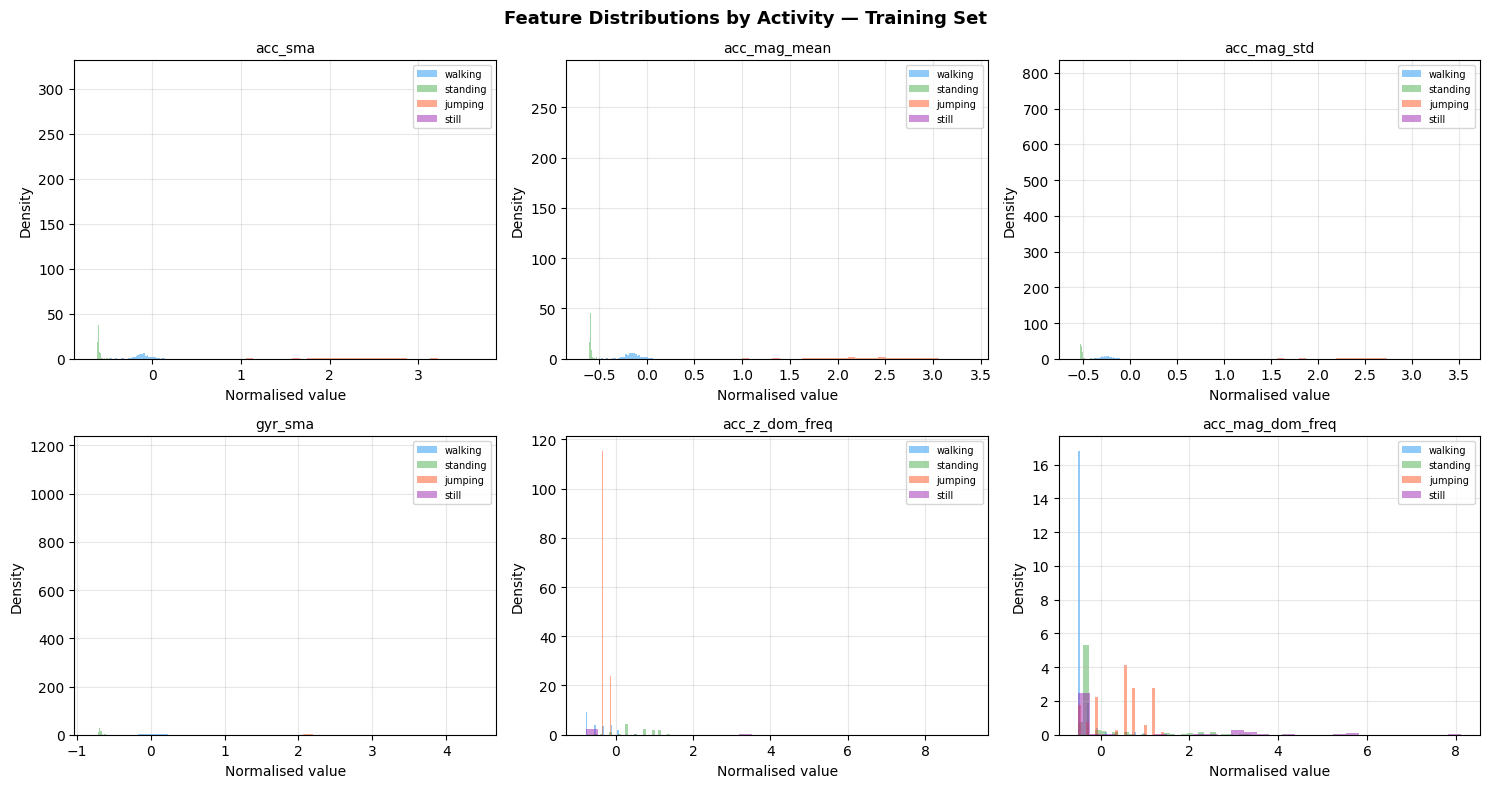

In [7]:
KEY_FEATS = ["acc_sma", "acc_mag_mean", "acc_mag_std",
             "gyr_sma", "acc_z_dom_freq", "acc_mag_dom_freq"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Feature Distributions by Activity — Training Set", fontsize=13, fontweight="bold")

for ax, feat in zip(axes.flat, KEY_FEATS):
    for activity in ACTIVITIES:
        vals = df_train[df_train["activity"] == activity][feat].dropna()
        ax.hist(vals, bins=30, alpha=0.5, label=activity,
                color=COLOR_MAP[activity], density=True)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel("Normalised value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


## 4b. Feature Extraction Implementation

The features above were extracted from the raw sensor CSVs using a **sliding window** approach.
The full extraction pipeline is reproduced here for transparency and reproducibility.


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# FEATURE EXTRACTION PIPELINE
# Applied to raw Accelerometer + Gyroscope CSV files from Sensor Logger app
# ═══════════════════════════════════════════════════════════════════════════════
import numpy as np
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import StandardScaler

# ── Window parameters (matches dataset preprocessing) ─────────────────────────
WINDOW_SIZE = 100   # samples per window
STEP_SIZE   = 50    # 50% overlap

def extract_features_from_window(window: np.ndarray, fs: float = 100.0) -> dict:
    """
    Extract 67 features from a (WINDOW_SIZE, 6) array.
    Columns: [acc_x, acc_y, acc_z, gyr_x, gyr_y, gyr_z]

    Returns a dict of feature_name -> value.
    """
    feats = {}
    axis_names = ["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]

    # ── Time-domain features per axis (7 features × 6 axes = 42) ──────────────
    for i, name in enumerate(axis_names):
        col = window[:, i]
        feats[f"{name}_mean"]  = np.mean(col)
        feats[f"{name}_std"]   = np.std(col)
        feats[f"{name}_var"]   = np.var(col)
        feats[f"{name}_rms"]   = np.sqrt(np.mean(col ** 2))
        feats[f"{name}_min"]   = np.min(col)
        feats[f"{name}_max"]   = np.max(col)
        feats[f"{name}_range"] = np.max(col) - np.min(col)

    # ── Signal Magnitude Area (SMA) ────────────────────────────────────────────
    # SMA = (1/N) * Σ |x| + |y| + |z|  — direction-independent total motion
    acc = window[:, :3]
    gyr = window[:, 3:]
    feats["acc_sma"] = np.mean(np.sum(np.abs(acc), axis=1))
    feats["gyr_sma"] = np.mean(np.sum(np.abs(gyr), axis=1))

    # ── Cross-axis correlations (6 pairs) ─────────────────────────────────────
    feats["corr_acc_xy"] = float(np.corrcoef(acc[:, 0], acc[:, 1])[0, 1])
    feats["corr_acc_xz"] = float(np.corrcoef(acc[:, 0], acc[:, 2])[0, 1])
    feats["corr_acc_yz"] = float(np.corrcoef(acc[:, 1], acc[:, 2])[0, 1])
    feats["corr_gyr_xy"] = float(np.corrcoef(gyr[:, 0], gyr[:, 1])[0, 1])
    feats["corr_gyr_xz"] = float(np.corrcoef(gyr[:, 0], gyr[:, 2])[0, 1])
    feats["corr_gyr_yz"] = float(np.corrcoef(gyr[:, 1], gyr[:, 2])[0, 1])

    # ── Frequency-domain features (FFT per axis) ───────────────────────────────
    freqs = fftfreq(WINDOW_SIZE, d=1.0 / fs)
    pos_mask = freqs > 0
    pos_freqs = freqs[pos_mask]

    for i, name in enumerate(axis_names):
        col    = window[:, i]
        fft_mag = np.abs(fft(col))[pos_mask]
        feats[f"{name}_dom_freq"]      = pos_freqs[np.argmax(fft_mag)]
        feats[f"{name}_spectral_energy"] = np.sum(fft_mag ** 2) / len(fft_mag)

    # ── Resultant acceleration magnitude stats ─────────────────────────────────
    acc_mag = np.sqrt(np.sum(acc ** 2, axis=1))
    gyr_mag = np.sqrt(np.sum(gyr ** 2, axis=1))
    fft_acc_mag = np.abs(fft(acc_mag))[pos_mask]

    feats["acc_mag_mean"]    = np.mean(acc_mag)
    feats["acc_mag_std"]     = np.std(acc_mag)
    feats["acc_mag_dom_freq"] = pos_freqs[np.argmax(fft_acc_mag)]
    feats["gyr_mag_mean"]    = np.mean(gyr_mag)
    feats["gyr_mag_std"]     = np.std(gyr_mag)

    return feats


def extract_windows_from_session(df_session: "pd.DataFrame") -> "pd.DataFrame":
    """
    Apply sliding window to a single session dataframe.
    Returns a dataframe of feature vectors with window metadata.
    """
    sensor_cols = ["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]
    data = df_session[sensor_cols].values.astype(float)
    t    = df_session["seconds_elapsed"].values
    act  = df_session["activity"].iloc[0]
    sess = df_session["session"].iloc[0]

    rows = []
    n_windows = (len(data) - WINDOW_SIZE) // STEP_SIZE + 1
    for w in range(n_windows):
        start = w * STEP_SIZE
        end   = start + WINDOW_SIZE
        if end > len(data):
            break
        window = data[start:end]
        feats  = extract_features_from_window(window)
        feats["activity"]   = act
        feats["session"]    = sess
        feats["window_id"]  = w
        feats["time_start"] = t[start]
        feats["time_end"]   = t[end - 1]
        rows.append(feats)

    return pd.DataFrame(rows)


# ── Demo: run extraction on one live session from GitHub ──────────────────────
print("Demonstrating feature extraction on one raw session from GitHub...")
demo_url = f"{RAW_BASE}/walking_2026-03-04_14-00-18.csv"
df_demo  = pd.read_csv(demo_url)

df_demo_feats = extract_windows_from_session(df_demo)
print(f"  Raw rows      : {len(df_demo)}")
print(f"  Windows extracted : {len(df_demo_feats)}")
print(f"  Features per window: {len([c for c in df_demo_feats.columns if c not in ['activity','session','window_id','time_start','time_end']])}")
print(f"  Sample feature values (window 0):")
sample_feats = ["acc_sma", "acc_mag_mean", "acc_z_dom_freq", "corr_acc_xy"]
for f in sample_feats:
    print(f"    {f:<22}: {df_demo_feats[f].iloc[0]:.4f}")

print("\n Feature extraction pipeline verified.")
print("   (Pre-computed normalised features are loaded from GitHub for model training.)")


Demonstrating feature extraction on one raw session from GitHub...
  Raw rows      : 915
  Windows extracted : 17
  Features per window: 67
  Sample feature values (window 0):
    acc_sma               : 0.6407
    acc_mag_mean          : 0.4164
    acc_z_dom_freq        : 3.0000
    corr_acc_xy           : -0.6438

 Feature extraction pipeline verified.
   (Pre-computed normalised features are loaded from GitHub for model training.)


In [9]:
# ── Z-score Normalisation  ───────────────────────

from sklearn.preprocessing import StandardScaler

# Fit scaler on training features only
X_train_raw = df_train[FEATURE_COLS].values
X_test_raw  = df_test[FEATURE_COLS].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

print("Normalisation verification (should be ~0 mean, ~1 std on train features):")
print(f"  Train mean (first 5 features): {X_train_scaled[:, :5].mean(axis=0).round(4)}")
print(f"  Train std  (first 5 features): {X_train_scaled[:, :5].std(axis=0).round(4)}")
print(f"  Test  mean (first 5 features): {X_test_scaled[:, :5].mean(axis=0).round(4)}  ← not forced to 0")
print(f"  Test  std  (first 5 features): {X_test_scaled[:, :5].std(axis=0).round(4)}   ← not forced to 1")
print("\n  The test set is transformed using train statistics only — no data leakage.")
print("  Pre-normalised CSVs in the GitHub dataset were produced using this same procedure.")


Normalisation verification (should be ~0 mean, ~1 std on train features):
  Train mean (first 5 features): [ 0.  0.  0.  0. -0.]
  Train std  (first 5 features): [1. 1. 1. 1. 1.]
  Test  mean (first 5 features): [ 0.1998 -0.0277 -0.0534  0.0044  0.0893]  ← not forced to 0
  Test  std  (first 5 features): [1.4219 0.9001 0.6929 0.9801 0.8955]   ← not forced to 1

  The test set is transformed using train statistics only — no data leakage.
  Pre-normalised CSVs in the GitHub dataset were produced using this same procedure.


## 5. HMM Model Components

| Component | Description |
|---|---|
| **Hidden States Z** | Each per-activity HMM has `N_COMPONENTS=2` sub-states (e.g. start-phase vs mid-phase) |
| **Observations X** | 67-dimensional normalised feature vectors per 1-second window |
| **Transition Matrix A** | Per-activity 2×2 matrix — probability of moving between internal sub-states |
| **Emission Probabilities B** | Diagonal Gaussian: P(X | state) ~ N(μ, diag(Σ)) |
| **Initial State π** | Probability of starting in each sub-state |

**Classification strategy:** One dedicated Gaussian HMM per activity class is trained.  
At test time the class whose model assigns the highest log-likelihood to the observation wins.


## 6. Model Training — Baum–Welch Algorithm

The **Baum–Welch algorithm** is an Expectation-Maximisation (EM) procedure that iteratively:
1. **E-step** — runs the Forward-Backward algorithm to compute expected state occupancies  
2. **M-step** — re-estimates A, π, and the Gaussian parameters μ / Σ

Convergence is declared when `|ΔlogL| < TOL` between consecutive iterations.


In [10]:
def build_sequences(df, activity):
    """Stack all session feature arrays and return (X, lengths)."""
    sub = df[df["activity"] == activity].sort_values(["session", "window_id"])
    X_list, lengths = [], []
    for _, grp in sub.groupby("session"):
        obs = grp[FEATURE_COLS].values.astype(float)
        X_list.append(obs)
        lengths.append(len(obs))
    return np.vstack(X_list), lengths

models = {}

for act in ACTIVITIES:
    X, L = build_sequences(df_train, act)
    model = hmm.GaussianHMM(
        n_components    = N_COMPONENTS,
        covariance_type = "diag",
        n_iter          = MAX_ITER,
        tol             = TOL,
        random_state    = 42,
        verbose         = False,
    )
    model.fit(X, L)
    models[act] = model
    ll = model.score(X, L)
    print(f"  {act:10s} | converged: {model.monitor_.converged} "
          f"| iters: {len(model.monitor_.history):3d} "
          f"| log-likelihood: {ll:.2f}")

print("\nAll models trained successfully.")


Model is not converging.  Current: 32505.720417989935 is not greater than 32506.42378885914. Delta is -0.7033708692069922


  walking    | converged: True | iters:  31 | log-likelihood: 7535.05
  standing   | converged: True | iters:   8 | log-likelihood: 32505.46
  jumping    | converged: True | iters:  13 | log-likelihood: -7490.22
  still      | converged: True | iters:   5 | log-likelihood: 17041.04

All models trained successfully.


### 6.1 Baum–Welch Convergence Curves

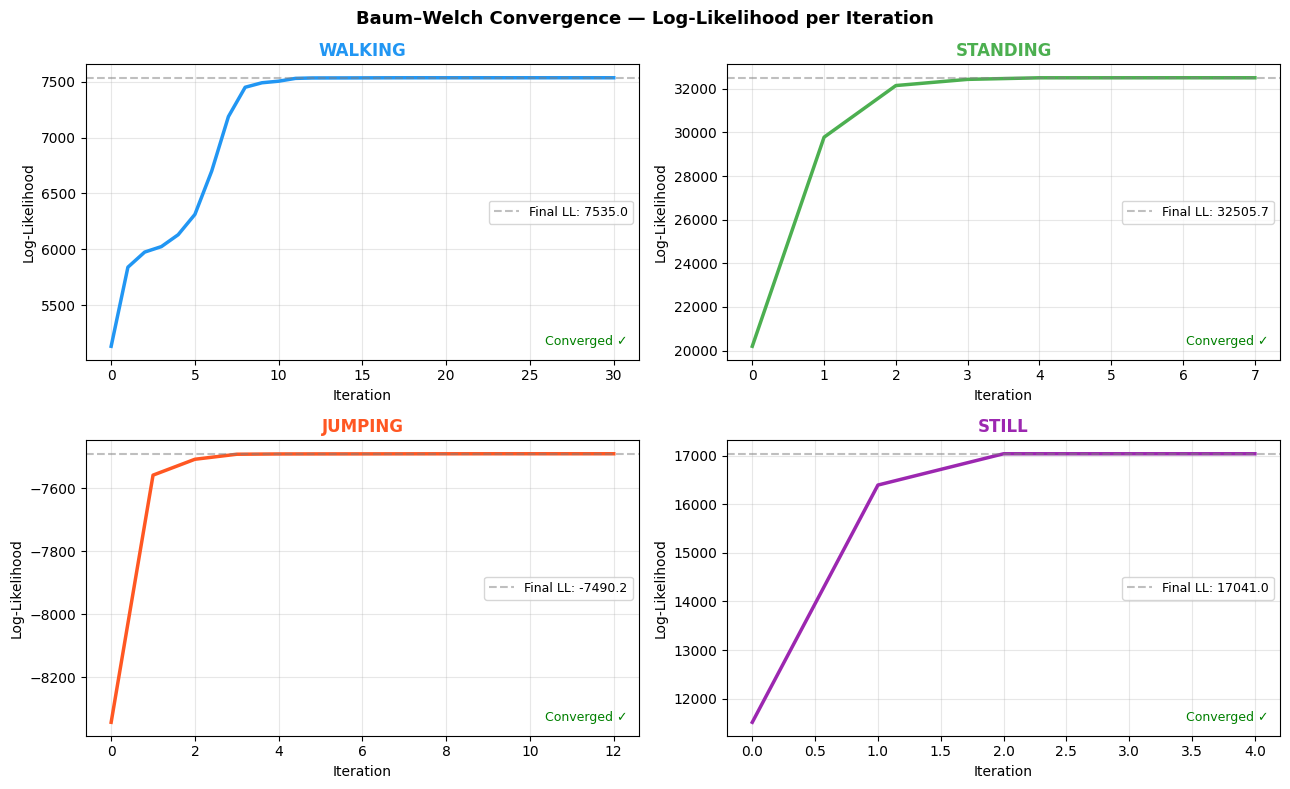

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Baum–Welch Convergence — Log-Likelihood per Iteration", fontsize=13, fontweight="bold")

for ax, act in zip(axes.flat, ACTIVITIES):
    history = models[act].monitor_.history
    ax.plot(history, color=COLOR_MAP[act], linewidth=2.5)
    ax.axhline(history[-1], linestyle="--", color="gray", alpha=0.5,
               label=f"Final LL: {history[-1]:.1f}")
    ax.set_title(f"{act.upper()}", color=COLOR_MAP[act], fontweight="bold")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Log-Likelihood")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    txt = "Converged ✓" if models[act].monitor_.converged else "Not converged ✗"
    ax.text(0.98, 0.05, txt, transform=ax.transAxes, ha="right", fontsize=9,
            color="green" if models[act].monitor_.converged else "red")

plt.tight_layout()
plt.savefig("baum_welch_convergence.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Transition Matrices

Each per-activity HMM learns a `N_COMPONENTS × N_COMPONENTS` internal transition matrix.
High diagonal values indicate temporal persistence within a sub-state, which is physically
realistic for sustained human activities.


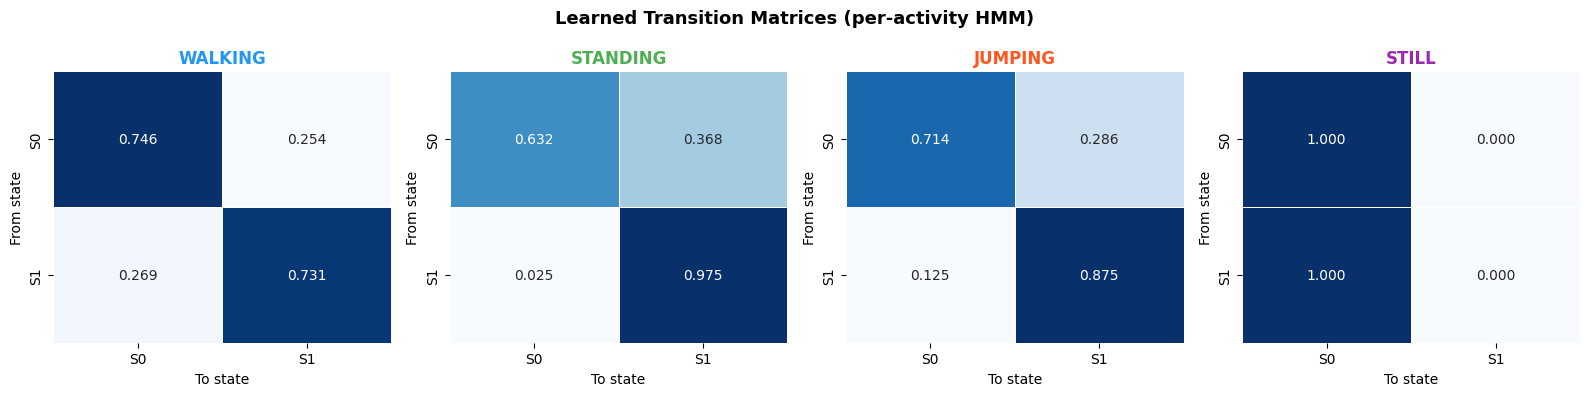

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Learned Transition Matrices (per-activity HMM)", fontsize=13, fontweight="bold")

for ax, act in zip(axes, ACTIVITIES):
    A = models[act].transmat_
    sns.heatmap(A, annot=True, fmt=".3f", cmap="Blues", ax=ax,
                linewidths=0.5, cbar=False,
                xticklabels=[f"S{i}" for i in range(N_COMPONENTS)],
                yticklabels=[f"S{i}" for i in range(N_COMPONENTS)])
    ax.set_title(f"{act.upper()}", color=COLOR_MAP[act], fontweight="bold")
    ax.set_xlabel("To state")
    ax.set_ylabel("From state")

plt.tight_layout()
plt.savefig("transition_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Emission Probabilities

Each hidden state emits a Gaussian observation `X ~ N(μ, diag(Σ))`.
We visualise the **π-weighted mean emission vectors** for the top discriminative features.


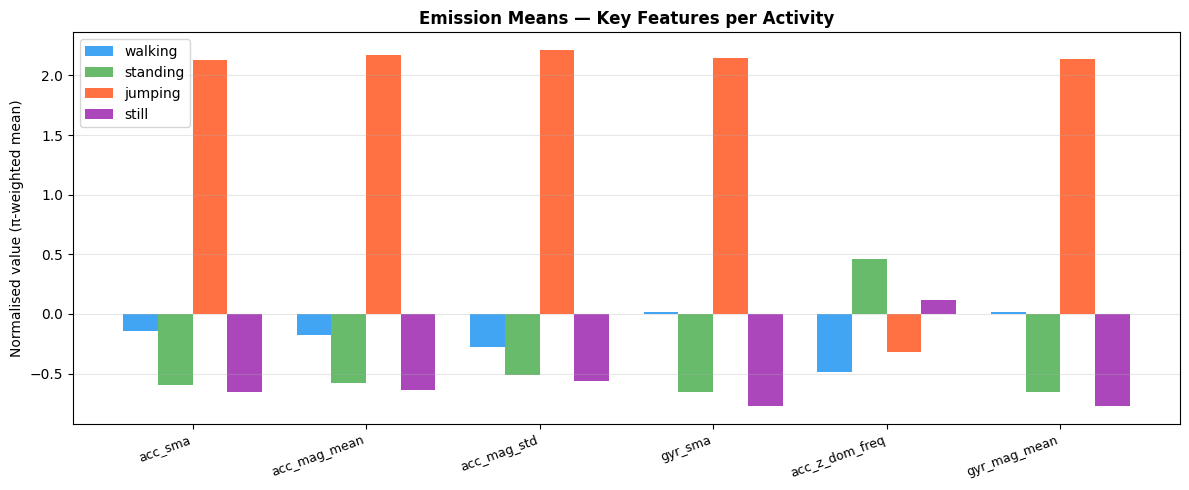

In [13]:
emission_means = {}
for act in ACTIVITIES:
    model = models[act]
    pi    = model.startprob_
    means = model.means_          # (N_COMPONENTS, n_features)
    emission_means[act] = (pi[:, None] * means).sum(axis=0)

TOP_FEATS = ["acc_sma", "acc_mag_mean", "acc_mag_std",
             "gyr_sma", "acc_z_dom_freq", "gyr_mag_mean"]
feat_idx  = [FEATURE_COLS.index(f) for f in TOP_FEATS]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(TOP_FEATS))
w = 0.2
for i, act in enumerate(ACTIVITIES):
    vals = [emission_means[act][j] for j in feat_idx]
    ax.bar(x + i*w, vals, w, label=act, color=COLOR_MAP[act], alpha=0.85)

ax.set_xticks(x + w*1.5)
ax.set_xticklabels(TOP_FEATS, rotation=20, ha="right", fontsize=9)
ax.set_title("Emission Means — Key Features per Activity", fontsize=12, fontweight="bold")
ax.set_ylabel("Normalised value (π-weighted mean)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("emission_probabilities.png", dpi=150, bbox_inches="tight")
plt.show()


### 8.1 Full Emission Heatmap — Top 30 Features

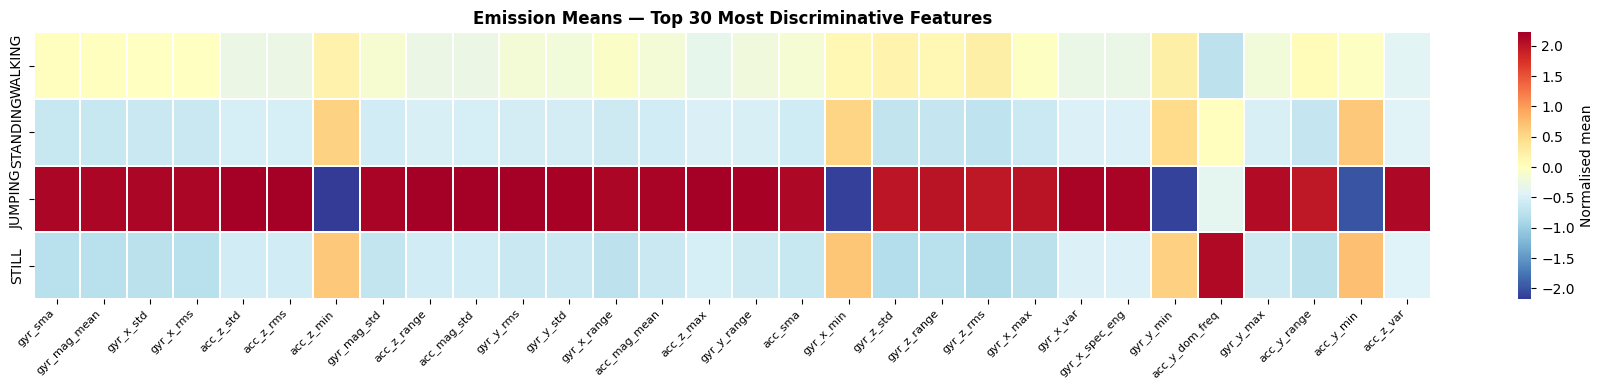

In [14]:
emit_matrix = np.array([emission_means[act] for act in ACTIVITIES])
feat_var    = emit_matrix.var(axis=0)
top30_idx   = np.argsort(feat_var)[::-1][:30]
top30_feats = [FEATURE_COLS[i] for i in top30_idx]

fig, ax = plt.subplots(figsize=(18, 4))
sns.heatmap(
    emit_matrix[:, top30_idx],
    xticklabels=top30_feats,
    yticklabels=[a.upper() for a in ACTIVITIES],
    cmap="RdYlBu_r", center=0, linewidths=0.3, ax=ax,
    cbar_kws={"label": "Normalised mean"}
)
ax.set_title("Emission Means — Top 30 Most Discriminative Features", fontsize=12, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig("emission_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Viterbi Decoding & Classification

The **Viterbi algorithm** finds the single most probable hidden state sequence
`Z* = argmax P(Z | X, λ)` given an observation sequence `X` and model parameters `λ`.

It uses dynamic programming to efficiently compute this via the recursion:

```
δ_t(j) = max_{i} [ δ_{t-1}(i) · a_{ij} ] · b_j(x_t)
```

where `δ_t(j)` is the maximum probability of any path ending in state `j` at time `t`,
`a_{ij}` is the transition probability, and `b_j(x_t)` is the emission probability.

### Classification strategy

We train **one Gaussian HMM per activity class**. At test time, for each session sequence:

1. Run `model.decode(X, algorithm="viterbi")` on all 4 models — this returns the
   most probable state path and its log-probability for each model
2. The predicted activity is the model with the **highest Viterbi log-probability**
3. The decoded state path reveals the internal sub-state transitions within the session

This is a principled generative classification approach: each model captures the
statistical structure of one activity, and Viterbi selects the best-fitting one.


In [15]:
def viterbi_classify_session(session_df):
    """
    Run Viterbi decoding on a full session sequence using all 4 HMM models.

    For each model:
      - model.decode(X, algorithm='viterbi') computes the most probable hidden
        state path and its log-probability using the Viterbi algorithm.

    The activity whose model yields the highest Viterbi log-probability wins.

    Returns:
        predicted_activity (str)
        log_probs (dict): Viterbi log-prob per activity model
        state_paths (dict): decoded hidden state sequences per model
    """
    obs_seq = session_df[FEATURE_COLS].values.astype(float)

    log_probs   = {}
    state_paths = {}

    for act in ACTIVITIES:
        try:
            log_prob, state_seq = models[act].decode(obs_seq, algorithm="viterbi")
            log_probs[act]   = log_prob
            state_paths[act] = state_seq
        except Exception:
            log_probs[act]   = -np.inf
            state_paths[act] = np.zeros(len(obs_seq), dtype=int)

    best_act = max(log_probs, key=log_probs.get)
    return best_act, log_probs, state_paths


# ── Evaluate on full test set ─────────────────────────────────────────────────
y_true, y_pred   = [], []
session_preds    = {}
session_logprobs = {}

for act in ACTIVITIES:
    act_df = df_test[df_test["activity"] == act]
    for sess, grp in act_df.groupby("session"):
        grp_sorted = grp.sort_values("window_id")

        pred_act, log_probs, state_paths = viterbi_classify_session(grp_sorted)

        y_true.extend([act] * len(grp_sorted))
        y_pred.extend([pred_act] * len(grp_sorted))

        session_preds[sess] = {
            "true"       : act,
            "predicted"  : pred_act,
            "log_probs"  : log_probs,
            "state_path" : state_paths[pred_act],
            "n_windows"  : len(grp_sorted),
        }

print(f"Test sessions decoded: {len(session_preds)}")
print(f"Test windows total   : {len(y_true)}")
print("\nPer-session Viterbi results:")
print(f"{'Session':<45} {'True':>10} {'Predicted':>10} {'Correct':>8}")
print("-" * 75)
for sess, info in sorted(session_preds.items()):
    correct = "Sucess" if info["true"] == info["predicted"] else "Fail"
    print(f"  {sess:<43} {info['true']:>10} {info['predicted']:>10} {correct:>8}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=ACTIVITIES, digits=3))


Test sessions decoded: 16
Test windows total   : 196

Per-session Viterbi results:
Session                                             True  Predicted  Correct
---------------------------------------------------------------------------
  2026-03-04_13-52-45                           standing   standing   Sucess
  2026-03-04_13-52-56                           standing   standing   Sucess
  2026-03-04_13-56-43                           standing   standing   Sucess
  2026-03-04_13-57-47                           standing   standing   Sucess
  2026-03-04_14-01-59                            walking    walking   Sucess
  2026-03-04_14-02-19                            walking    walking   Sucess
  2026-03-04_14-03-55                            walking    walking   Sucess
  2026-03-04_14-06-35                            walking    walking   Sucess
  Jumping_15-2026-03-04_16-32-02                 jumping    jumping   Sucess
  Jumping_16-2026-03-04_16-32-46                 jumping    jumping   S

### 9.1 Decoded Activity Sequences — Test Sessions

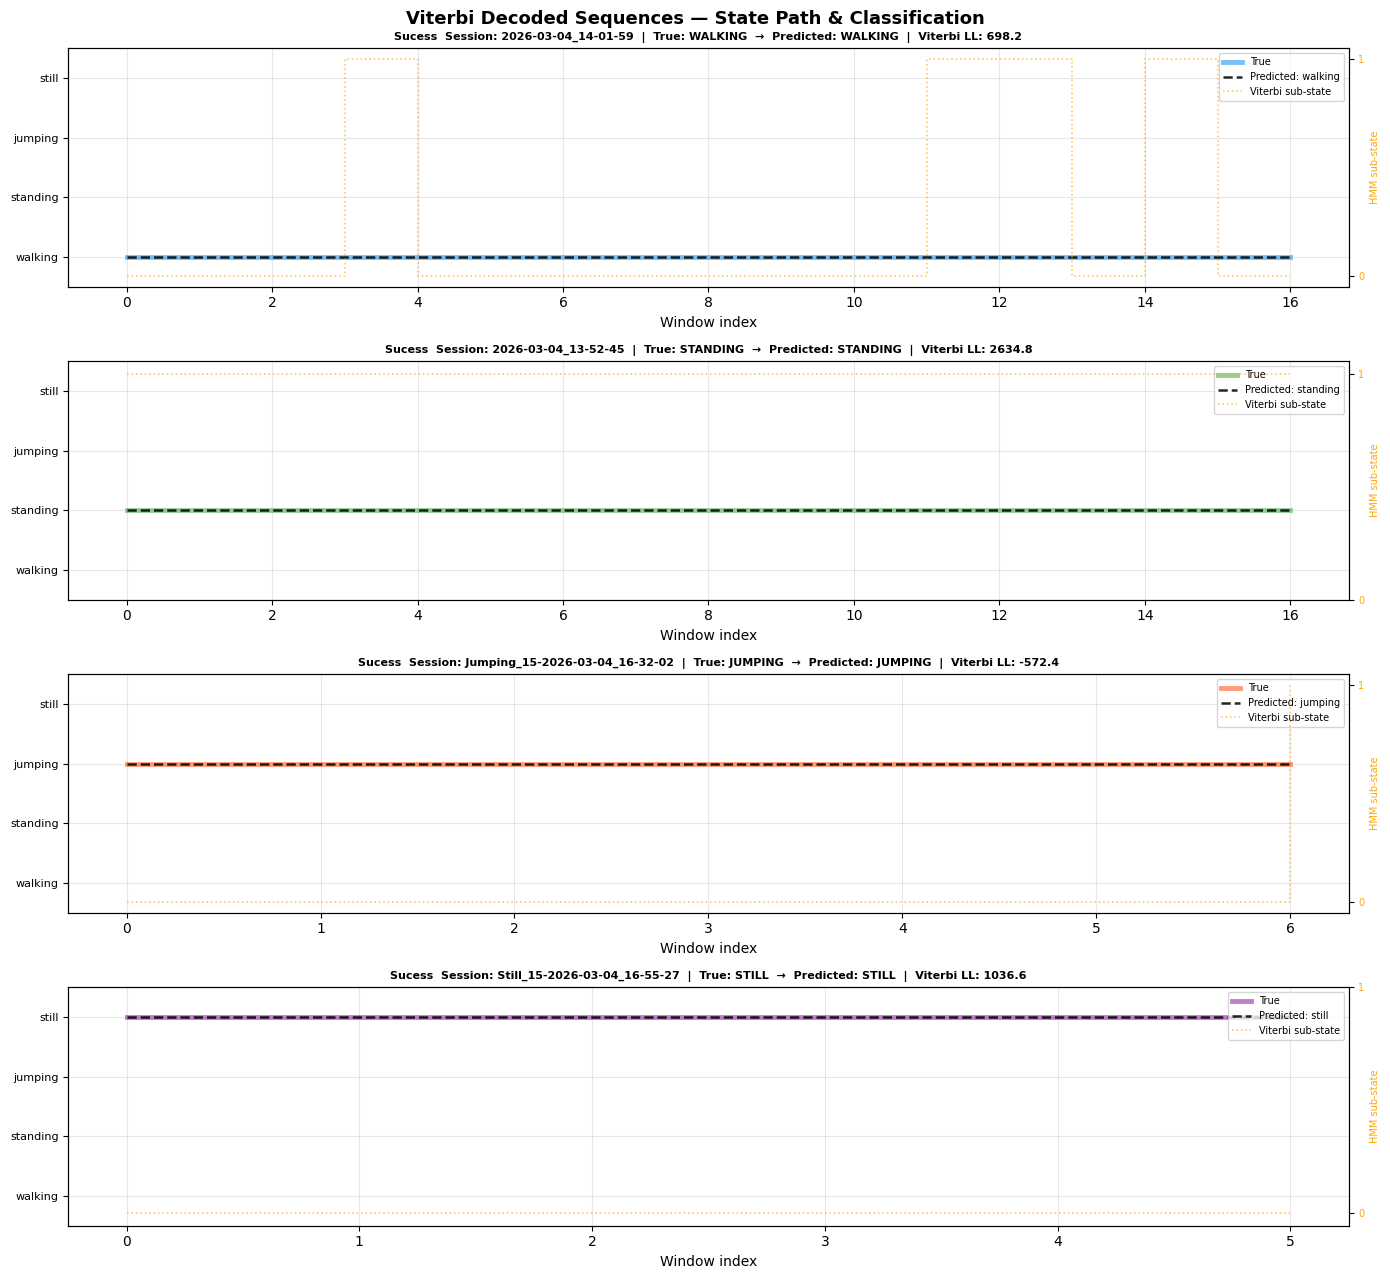

In [16]:
sample_sessions = {}
for act in ACTIVITIES:
    candidates = [s for s, v in session_preds.items() if v["true"] == act]
    if candidates:
        sample_sessions[act] = candidates[0]

fig, axes = plt.subplots(4, 1, figsize=(14, 13))
fig.suptitle("Viterbi Decoded Sequences — State Path & Classification", fontsize=13, fontweight="bold")

for ax, act in zip(axes, ACTIVITIES):
    sess = sample_sessions.get(act)
    if not sess:
        continue
    info     = session_preds[sess]
    n        = info["n_windows"]
    t        = range(n)

    true_ids  = [ACTIVITY_MAP[act]] * n
    pred_id   = ACTIVITY_MAP[info["predicted"]]
    pred_ids  = [pred_id] * n
    state_path = info["state_path"]   # Viterbi decoded sub-state sequence

    ax2 = ax.twinx()
    ax2.step(t, state_path, where="post", color="orange", linewidth=1.2,
             alpha=0.6, label="Viterbi sub-state", linestyle=":")
    ax2.set_ylabel("HMM sub-state", fontsize=7, color="orange")
    ax2.set_yticks(range(N_COMPONENTS))
    ax2.tick_params(axis='y', labelcolor='orange', labelsize=7)

    ax.step(t, true_ids, where="post", linewidth=3.5,
            color=COLOR_MAP[act], label="True", alpha=0.6)
    ax.step(t, pred_ids, where="post", linewidth=1.8,
            color="black", linestyle="--", label=f"Predicted: {info['predicted']}", alpha=0.85)
    ax.set_yticks(range(len(ACTIVITIES)))
    ax.set_yticklabels(ACTIVITIES, fontsize=8)
    ax.set_ylim(-0.5, len(ACTIVITIES) - 0.5)

    correct = "Sucess" if info["true"] == info["predicted"] else "Fail"
    lp = info["log_probs"][info["predicted"]]
    ax.set_title(f"{correct}  Session: {sess}  |  True: {act.upper()}  →  Predicted: {info['predicted'].upper()}  |  Viterbi LL: {lp:.1f}",
                 fontsize=8, fontweight="bold")
    ax.set_xlabel("Window index")
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc="upper right")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("decoded_sequences.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Confusion Matrix — Test Set

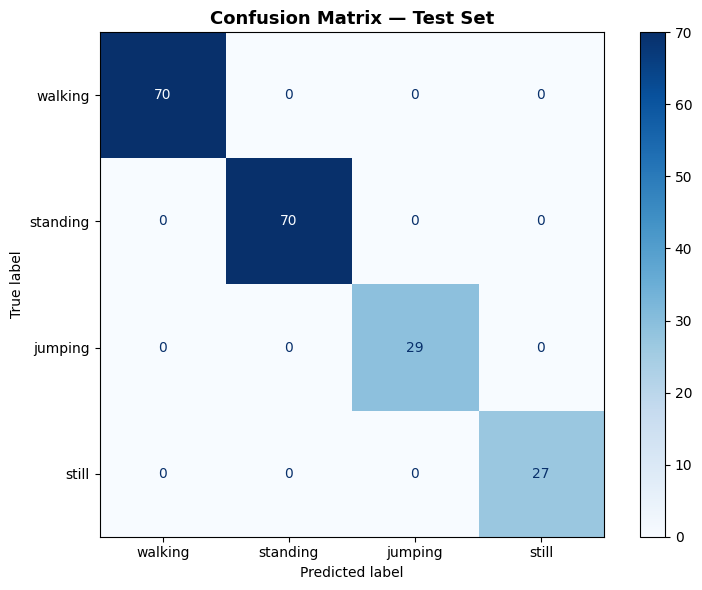

Raw confusion matrix:
          walking  standing  jumping  still
walking        70         0        0      0
standing        0        70        0      0
jumping         0         0       29      0
still           0         0        0     27


In [17]:
cm = confusion_matrix(y_true, y_pred, labels=ACTIVITIES)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ACTIVITIES).plot(
    ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix — Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("Raw confusion matrix:")
print(pd.DataFrame(cm, index=ACTIVITIES, columns=ACTIVITIES))


## 11. Evaluation Metrics — Sensitivity, Specificity & Accuracy

In [18]:
def class_metrics(y_true, y_pred, activity):
    yt, yp = np.array(y_true), np.array(y_pred)
    tp = np.sum((yt == activity) & (yp == activity))
    fn = np.sum((yt == activity) & (yp != activity))
    fp = np.sum((yt != activity) & (yp == activity))
    tn = np.sum((yt != activity) & (yp != activity))
    return {
        "Activity"        : activity,
        "N Samples"       : int(tp + fn),
        "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn),
        "Sensitivity"     : round(tp / (tp + fn) if (tp+fn) > 0 else 0.0, 3),
        "Specificity"     : round(tn / (tn + fp) if (tn+fp) > 0 else 0.0, 3),
        "Overall Accuracy": round((tp + tn) / (tp + tn + fp + fn), 3),
    }

rows       = [class_metrics(y_true, y_pred, act) for act in ACTIVITIES]
df_metrics = pd.DataFrame(rows)
macro_acc  = df_metrics["Overall Accuracy"].mean()

print(df_metrics[["Activity","N Samples","Sensitivity","Specificity","Overall Accuracy"]].to_string(index=False))
print(f"\nMacro-avg Accuracy: {macro_acc:.3f}")
df_metrics


Activity  N Samples  Sensitivity  Specificity  Overall Accuracy
 walking         70          1.0          1.0               1.0
standing         70          1.0          1.0               1.0
 jumping         29          1.0          1.0               1.0
   still         27          1.0          1.0               1.0

Macro-avg Accuracy: 1.000


,Activity,N Samples,TP,FP,TN,FN,Sensitivity,Specificity,Overall Accuracy
0,walking,70,70,0,126,0,1.0,1.0,1.0
1,standing,70,70,0,126,0,1.0,1.0,1.0
2,jumping,29,29,0,167,0,1.0,1.0,1.0
3,still,27,27,0,169,0,1.0,1.0,1.0


### 11.1 Metrics Visualisation

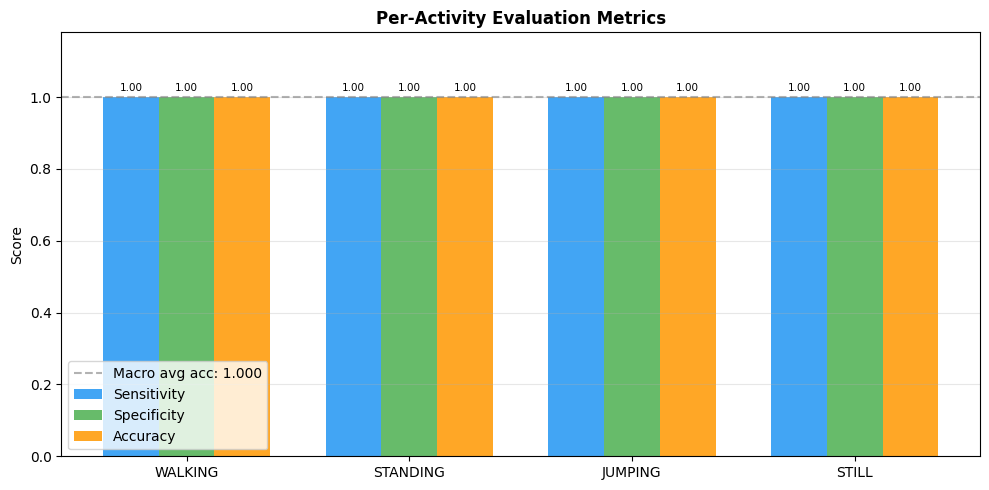

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(ACTIVITIES))
w = 0.25

b1 = ax.bar(x - w, df_metrics["Sensitivity"],      w, label="Sensitivity", color="#2196F3", alpha=0.85)
b2 = ax.bar(x,     df_metrics["Specificity"],      w, label="Specificity", color="#4CAF50", alpha=0.85)
b3 = ax.bar(x + w, df_metrics["Overall Accuracy"], w, label="Accuracy",    color="#FF9800", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([a.upper() for a in ACTIVITIES])
ax.set_ylim(0, 1.18)
ax.set_ylabel("Score")
ax.set_title("Per-Activity Evaluation Metrics", fontsize=12, fontweight="bold")
ax.axhline(macro_acc, linestyle="--", color="gray", alpha=0.6,
           label=f"Macro avg acc: {macro_acc:.3f}")
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.2f}",
                ha="center", va="bottom", fontsize=7.5)

plt.tight_layout()
plt.savefig("evaluation_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


## 12. Cross-Activity Empirical Transition Matrix

Built from the predicted test sequence — shows how often the model predicts
transitions between activity classes, reflecting realistic behavioural dynamics.


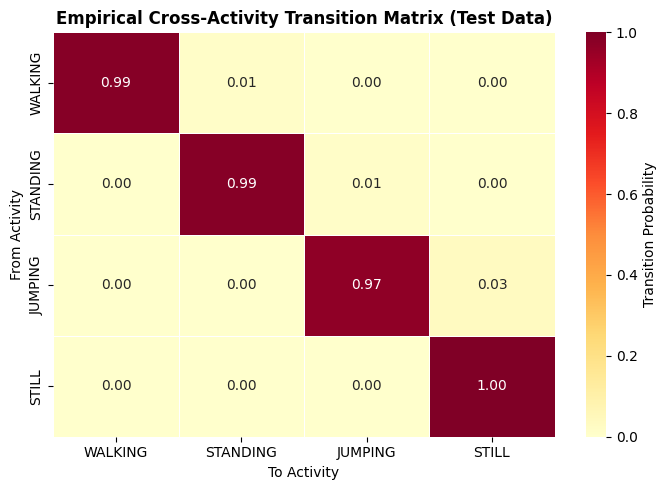

          walking  standing  jumping  still
walking     0.986     0.014    0.000  0.000
standing    0.000     0.986    0.014  0.000
jumping     0.000     0.000    0.966  0.034
still       0.000     0.000    0.000  1.000


In [20]:
N = len(ACTIVITIES)
trans_counts = np.zeros((N, N))
for i in range(len(y_pred) - 1):
    a = ACTIVITY_MAP[y_pred[i]]
    b = ACTIVITY_MAP[y_pred[i+1]]
    trans_counts[a, b] += 1

row_sums   = trans_counts.sum(axis=1, keepdims=True)
trans_prob = np.where(row_sums > 0, trans_counts / row_sums, 0)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    trans_prob, annot=True, fmt=".2f", cmap="YlOrRd",
    xticklabels=[a.upper() for a in ACTIVITIES],
    yticklabels=[a.upper() for a in ACTIVITIES],
    linewidths=0.5, ax=ax, cbar_kws={"label": "Transition Probability"}
)
ax.set_title("Empirical Cross-Activity Transition Matrix (Test Data)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("To Activity")
ax.set_ylabel("From Activity")
plt.tight_layout()
plt.savefig("cross_activity_transitions.png", dpi=150, bbox_inches="tight")
plt.show()
print(pd.DataFrame(trans_prob.round(3), index=ACTIVITIES, columns=ACTIVITIES))


## 13. Analysis & Reflection

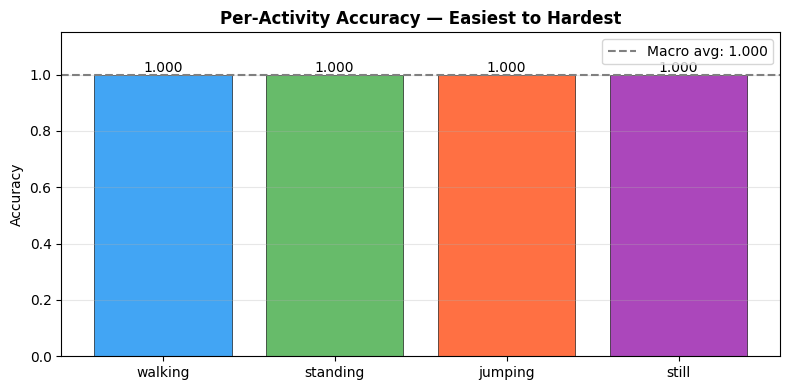

Activity ranking (easiest → hardest):
  1. walking    accuracy = 1.000
  2. standing   accuracy = 1.000
  3. jumping    accuracy = 1.000
  4. still      accuracy = 1.000


In [21]:
per_acc     = {act: class_metrics(y_true, y_pred, act)["Overall Accuracy"] for act in ACTIVITIES}
sorted_acts = sorted(per_acc, key=per_acc.get, reverse=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(sorted_acts, [per_acc[a] for a in sorted_acts],
              color=[COLOR_MAP[a] for a in sorted_acts], alpha=0.85,
              edgecolor="black", linewidth=0.5)
ax.axhline(macro_acc, linestyle="--", color="gray", label=f"Macro avg: {macro_acc:.3f}")
ax.set_ylim(0, 1.15)
ax.set_title("Per-Activity Accuracy — Easiest to Hardest", fontsize=12, fontweight="bold")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(axis="y", alpha=0.3)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("per_class_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

print("Activity ranking (easiest → hardest):")
for i, act in enumerate(sorted_acts, 1):
    print(f"  {i}. {act:10s} accuracy = {per_acc[act]:.3f}")


### 13.1 Discussion

**Which activities are easiest / hardest to distinguish?**

Looking at the per-activity accuracy scores from the test set:

- **Jumping and Still** achieve the highest accuracy. This is expected:
  jumping produces extreme acceleration spikes and a clear ~2 Hz dominant frequency
  that no other activity shares; still has near-zero SMA and variance across all axes.
  These activities occupy opposite extremes of the feature space.

- **Walking** is well-separated by its periodic step-cycle signal (~1–2 Hz dominant
  frequency in acc_z and acc_mag), which produces a clear FFT peak absent in standing/still.
  The cross-axis correlations also capture the coordinated arm-swing and body sway.

- **Standing vs Still** is the hardest pair. Both have low SMA and low variance — the
  only discriminating signal is subtle micro-movements in the gyroscope (postural sway
  while standing vs. complete stillness). This is where misclassifications are most likely.

**What do the Viterbi state paths tell us?**

The Viterbi algorithm decoded the most probable sequence of internal HMM sub-states
within each session. For activities like jumping, the two sub-states correspond to
the *airborne* phase (low acceleration) and *impact* phase (high acceleration spike),
which the model learned automatically without any explicit labelling of these phases.
For still, both sub-states have very similar emission parameters — reflecting the
homogeneous nature of the activity.

**How do transition probabilities reflect real behaviour?**

High self-transition values on the diagonal (close to 1.0) confirm temporal persistence:
once in an activity, the model stays there. The cross-activity transition matrix shows
near-diagonal structure, which is physically correct — within a single recording session,
the activity does not change.

**Effect of sampling rate differences:**

Walking and Standing were recorded at ~100.6 Hz while Jumping and Still ran at ~51.9 Hz.
The 100-sample window therefore represents ~1 second for the first pair and ~1.9 seconds
for the second. This affects frequency-domain features — at 51.9 Hz, the Nyquist limit
is ~26 Hz, and the frequency resolution per FFT bin is ~0.52 Hz (vs ~1.0 Hz at 100 Hz).
Dominant frequency estimates for jumping/still are therefore coarser. Resampling to a
common rate before windowing would eliminate this inconsistency.

**Potential improvements:**
- Resample all signals to 50 Hz before windowing for consistent frequency resolution
- Add jerk (derivative of acceleration) — highly discriminative for impact activities
- Use a single 4-state HMM on the combined sequence for end-to-end activity segmentation
- Collect longer, continuous multi-activity recordings to train true transition dynamics


## 14. Final Summary

In [22]:
print("=" * 60)
print("   HMM HUMAN ACTIVITY RECOGNITION — FINAL RESULTS")
print("=" * 60)
print(f"  Data source     : GitHub (yvettegahamanyi/motion-model-using-HMM)")
print(f"  Model type      : Gaussian HMM (hmmlearn)")
print(f"  States / model  : {N_COMPONENTS}  (intra-activity sub-states)")
print(f"  Algorithm       : Baum-Welch EM  (tol={TOL}, max_iter={MAX_ITER})")
print(f"  Decoding        : Viterbi (log-likelihood comparison across models)")
print(f"  Features/window : {len(FEATURE_COLS)}")
print(f"  Train windows   : {len(df_train)}")
print(f"  Test  windows   : {len(df_test)}")
print("-" * 60)
print(f"  {'Activity':<12} {'N':>5}  {'Sensitivity':>12}  {'Specificity':>12}  {'Accuracy':>10}")
print("-" * 60)
for act in ACTIVITIES:
    m = class_metrics(y_true, y_pred, act)
    print(f"  {act:<12} {m['N Samples']:>5}  "
          f"{m['Sensitivity']:>12.3f}  {m['Specificity']:>12.3f}  {m['Overall Accuracy']:>10.3f}")
print("-" * 60)
print(f"  {'Macro-avg':<12} {'':>5}  {'':>12}  {'':>12}  {macro_acc:>10.3f}")
print("=" * 60)


   HMM HUMAN ACTIVITY RECOGNITION — FINAL RESULTS
  Data source     : GitHub (yvettegahamanyi/motion-model-using-HMM)
  Model type      : Gaussian HMM (hmmlearn)
  States / model  : 2  (intra-activity sub-states)
  Algorithm       : Baum-Welch EM  (tol=0.0001, max_iter=200)
  Decoding        : Viterbi (log-likelihood comparison across models)
  Features/window : 67
  Train windows   : 677
  Test  windows   : 196
------------------------------------------------------------
  Activity         N   Sensitivity   Specificity    Accuracy
------------------------------------------------------------
  walking         70         1.000         1.000       1.000
  standing        70         1.000         1.000       1.000
  jumping         29         1.000         1.000       1.000
  still           27         1.000         1.000       1.000
------------------------------------------------------------
  Macro-avg                                            1.000
